# Regressão logística binária

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Classificar observações e ler probabilidades e erros por classe.

**Pergunta-guia:** Quantos positivos o modelo deixa passar? A acurácia resume esse problema?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

Relatorio de classificacao:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.50      0.67         6

    accuracy                           0.85        20
   macro avg       0.91      0.75      0.78        20
weighted avg       0.88      0.85      0.83        20

Matriz de confusao:
 [[14  0]
 [ 3  3]]


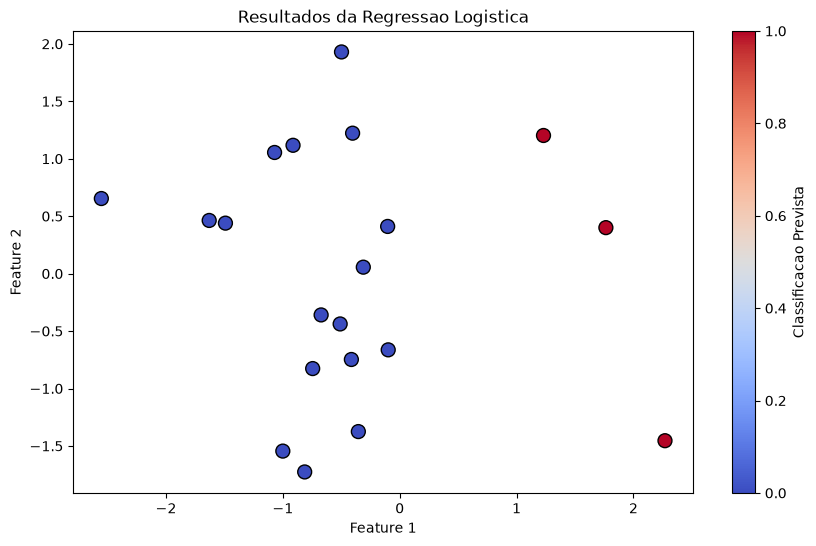

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados do arquivo CSV
dados = pd.read_csv(resolve_data_path("8.0 - dados_logistic_regression.csv"))

# Separar as variaveis independentes e dependentes
X = dados[['Feature1', 'Feature2']].values
y = dados['Target'].values

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo de regressao logistica
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Realizar previsoes com o modelo
y_pred = modelo.predict(X_test)

# Avaliar o modelo
print("Relatorio de classificacao:\n", classification_report(y_test, y_pred))
print("Matriz de confusao:\n", confusion_matrix(y_test, y_pred))

# Visualizacao dos resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', marker='o', edgecolor='k', s=100)
plt.title('Resultados da Regressao Logistica')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Classificacao Prevista')
plt.show()

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
from sklearn.metrics import precision_score, recall_score
X_ajuste, X_valid, y_ajuste, y_valid = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=1)
modelo_valid = LogisticRegression(max_iter=1000).fit(X_ajuste, y_ajuste)
prob_valid = modelo_valid.predict_proba(X_valid)[:, 1]
for limiar in (0.3, 0.5, 0.7):
    previsto = (prob_valid >= limiar).astype(int)
    print(f'limiar={limiar}: precisão validação={precision_score(y_valid, previsto, zero_division=0):.2f}; recall validação={recall_score(y_valid, previsto, zero_division=0):.2f}')
print('Escolha o limiar na validação conforme o custo dos erros; preserve o teste para a avaliação final.')
print('Matriz: linhas=real, colunas=previsto; falso negativo=[1,0].')

limiar=0.3: precisão validação=0.78; recall validação=0.78
limiar=0.5: precisão validação=0.83; recall validação=0.56
limiar=0.7: precisão validação=1.00; recall validação=0.33
Escolha o limiar na validação conforme o custo dos erros; preserve o teste para a avaliação final.
Matriz: linhas=real, colunas=previsto; falso negativo=[1,0].


## Interpretação e limites

O limiar 0,5 é uma escolha e deve refletir o custo dos erros.

## Exercício

Varie o limiar usando apenas uma validação separada; compare precisão e recall.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.